# Pharmacy Desert Risk Prediction Using Machine Learning

## Week 3 – Exploratory Data Analysis

In [1]:
# General Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

## Loading Data

Importing the merged dataset

In [2]:
# Data Importation
# Getting cleaned and merged per state data
df = pd.read_csv("df_final_pharmacy_cleaned.csv")
# Getting Overview
df.head()


,State_y,County,county_fips,year,pharmacies_per_county_year,tot_claims,tot_30day_fills,tot_drug_cost,tot_days_supply,tot_beneficiaries,avg_bene_age,Health_Outcome_Rank,Health_Factor_Rank,labor_force,employed,unemployed,unemployment_rate
0,AK,Aleutians East,2013,2014,0,1543,2515.200000,101236.20,69125,252,72.206522,16.0,16.0,2219,2121,98,4.4
1,AK,Aleutians East,2013,2015,1,1265,2095.733333,87137.34,58674,211,70.535299,16.0,16.0,2472,2395,77,3.1
2,AK,Aleutians East,2013,2016,2,1977,3104.066667,144648.87,84565,250,66.715694,16.0,16.0,2589,2523,66,2.5
3,AK,Aleutians East,2013,2018,2,1451,2550.366667,112767.33,67572,435,69.874315,16.0,16.0,2316,2250,66,2.8
4,AK,Aleutians East,2013,2019,1,92,136.433333,11567.95,2963,42,70.142857,16.0,16.0,2544,2483,61,2.4


# Feature Engineering for Target: Temporal Desert Formation

**Pharmacy Accessibility Pressure (PAP) Index** - measures the beneficiary load per pharmacy by dividing the total number of beneficiaries (tot_beneficiaries) by the total number of pharmacies in the given county. Given as bene_per_pharmacy_PAP

**Temporal Desert Formation (TDF) Feature** - Tracks the percentage change in the **Pharmacy Accessibility Pressure (PAP) Index** across years for each of the counties. Given as access_pressure_change_TDF and such that:

- Negative values = accessibility improved

- Near zero = stable accessibility

- Positive values = worsening accessibility

- Large positive values = rapid deterioration (potential desert formation)


**Desert_Formation_Risk** - Binary feature for a county as either at high risk or low risk of pharmacy desert formation based on the percentage change in the Pharmacy Accessibility Pressure (PAP) Index (≥25% change = High Risk, otherwise Low Risk).



In [3]:
# Creating the Pharmacy Accessibility Pressure  (PAP)
df["bene_per_pharmacy_PAP"] = (
    df["tot_beneficiaries"] /
    df["pharmacies_per_county_year"]
)

# Creating a lag for Accessibility Pressure Index
df["bene_per_pharmacy_PAP_lag"] = (
    df.groupby("county_fips")["bene_per_pharmacy_PAP"]
      .shift(1)
)


# Creating Temporal Desert Formation Feature
df["access_pressure_change_TDF"] = (
    (df["bene_per_pharmacy_PAP"] - df["bene_per_pharmacy_PAP_lag"])/df["bene_per_pharmacy_PAP_lag"]
)


In [4]:
# Pharmacy Desert Formation Risk Feature

df["Desert_Formation_Risk"] = np.where(
    df["access_pressure_change_TDF"] >= 0.25,
    "High Risk",
    "Low Risk"
)


In [5]:
# Replace inf and -inf with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Exploratory Data Analysis (EDA)

In [6]:
# Data Overview
df.head()

,State_y,County,county_fips,year,pharmacies_per_county_year,tot_claims,tot_30day_fills,tot_drug_cost,tot_days_supply,tot_beneficiaries,...,Health_Outcome_Rank,Health_Factor_Rank,labor_force,employed,unemployed,unemployment_rate,bene_per_pharmacy_PAP,bene_per_pharmacy_PAP_lag,access_pressure_change_TDF,Desert_Formation_Risk
0,AK,Aleutians East,2013,2014,0,1543,2515.200000,101236.20,69125,252,...,16.0,16.0,2219,2121,98,4.4,NaN,NaN,NaN,Low Risk
1,AK,Aleutians East,2013,2015,1,1265,2095.733333,87137.34,58674,211,...,16.0,16.0,2472,2395,77,3.1,211.0,NaN,NaN,Low Risk
2,AK,Aleutians East,2013,2016,2,1977,3104.066667,144648.87,84565,250,...,16.0,16.0,2589,2523,66,2.5,125.0,211.0,-0.407583,Low Risk
3,AK,Aleutians East,2013,2018,2,1451,2550.366667,112767.33,67572,435,...,16.0,16.0,2316,2250,66,2.8,217.5,125.0,0.740000,High Risk
4,AK,Aleutians East,2013,2019,1,92,136.433333,11567.95,2963,42,...,16.0,16.0,2544,2483,61,2.4,42.0,217.5,-0.806897,Low Risk


In [7]:
# Removing NaNs
df = df.dropna()
# Checking the structure
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16507 entries, 2 to 25188
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   State_y                     16507 non-null  object 
 1   County                      16507 non-null  object 
 2   county_fips                 16507 non-null  int64  
 3   year                        16507 non-null  int64  
 4   pharmacies_per_county_year  16507 non-null  int64  
 5   tot_claims                  16507 non-null  int64  
 6   tot_30day_fills             16507 non-null  float64
 7   tot_drug_cost               16507 non-null  float64
 8   tot_days_supply             16507 non-null  int64  
 9   tot_beneficiaries           16507 non-null  int64  
 10  avg_bene_age                16507 non-null  float64
 11  Health_Outcome_Rank         16507 non-null  float64
 12  Health_Factor_Rank          16507 non-null  float64
 13  labor_force                 16507 no

### State-level Average Change in Pharmacies' Access Pressure Change

The change in acess pressure from 2014 to 2023 provides an overall picture of the states that have overtime experienced greatest pharmacy deserts creation through highest increase in the access pressure change for access to pharmacies based on changes on year to year number of beneficiaries per pharmacy (beneficiary load). At state level the average highest increases in the access pressure change for access to pharmacies provided information on highest at risk states.

In [8]:

# Average county-level pressure by state-year
state_year = (
    df.groupby(['State_y', 'year'])['access_pressure_change_TDF']
      .mean()
      .reset_index()
)

# Earliest and latest years in dataset
first_year = state_year['year'].min()
last_year = state_year['year'].max()

# Extract values for first and last year
first = (
    state_year[state_year['year'] == first_year]
    [['State_y', 'access_pressure_change_TDF']]
    .rename(columns={'access_pressure_change_TDF': 'first_year_pressure'})
)

last = (
    state_year[state_year['year'] == last_year]
    [['State_y', 'access_pressure_change_TDF']]
    .rename(columns={'access_pressure_change_TDF': 'last_year_pressure'})
)

# Calculate change
state_change = (
    first.merge(last, on='State_y')
         .assign(
             pressure_change=lambda x:
             x['last_year_pressure'] - x['first_year_pressure']
         )
         .sort_values('pressure_change', ascending=False)
)

# Top 10 states with largest increase
top10_states = state_change.head(10)
top10_states

,State_y,first_year_pressure,last_year_pressure,pressure_change
22,NJ,-0.256233,1.855493,2.111726
11,KS,-0.918369,1.084229,2.002599
0,AK,-0.196952,1.704496,1.901448
8,IA,-0.993896,0.478137,1.472033
2,AR,-0.884450,0.579279,1.463729
14,MA,-0.517439,0.661732,1.179170
24,NV,-0.752799,0.335431,1.088230
38,WY,-0.929780,0.085430,1.015210
15,MD,-0.708501,0.305624,1.014125
5,CT,-0.971526,0.018677,0.990203


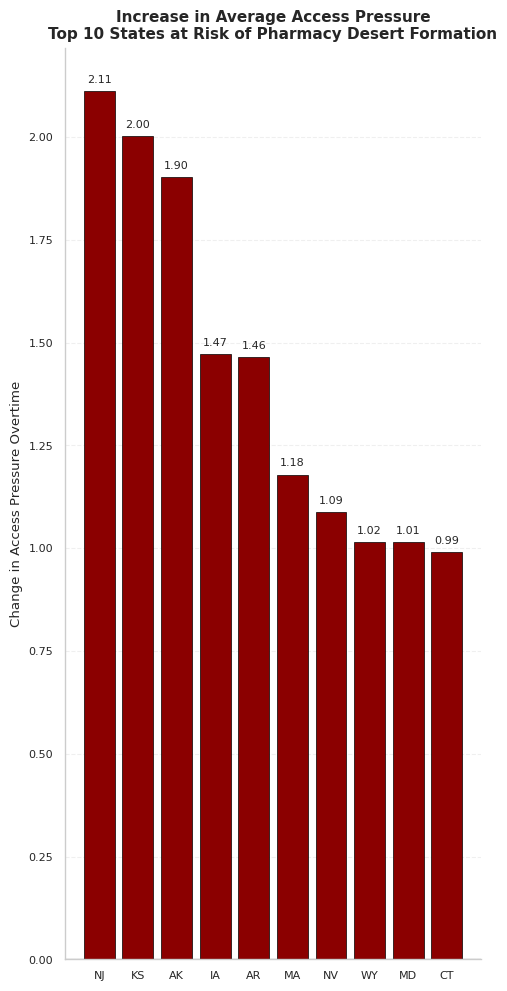

In [9]:
# Bar Chart
sns.set_theme(style="whitegrid", context="paper")

fig, ax = plt.subplots(figsize=(5, 10))

colors = ['#8B0000' if x > 0 else '#2F5D7E'
          for x in top10_states['pressure_change']]

bars = ax.bar(
    top10_states['State_y'],
    top10_states['pressure_change'],
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

# Value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f'{height:.2f}',
        ha='center',
        fontsize=8
    )

ax.set_title(
    f'Increase in Average Access Pressure\nTop 10 States at Risk of Pharmacy Desert Formation',
    fontsize=11,
    weight='bold'
)

ax.set_xlabel(
    '',
    fontsize=9
)

ax.set_ylabel('Change in Access Pressure Overtime')

ax.tick_params(labelsize=8)

ax.axhline(0, color='black', linewidth=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

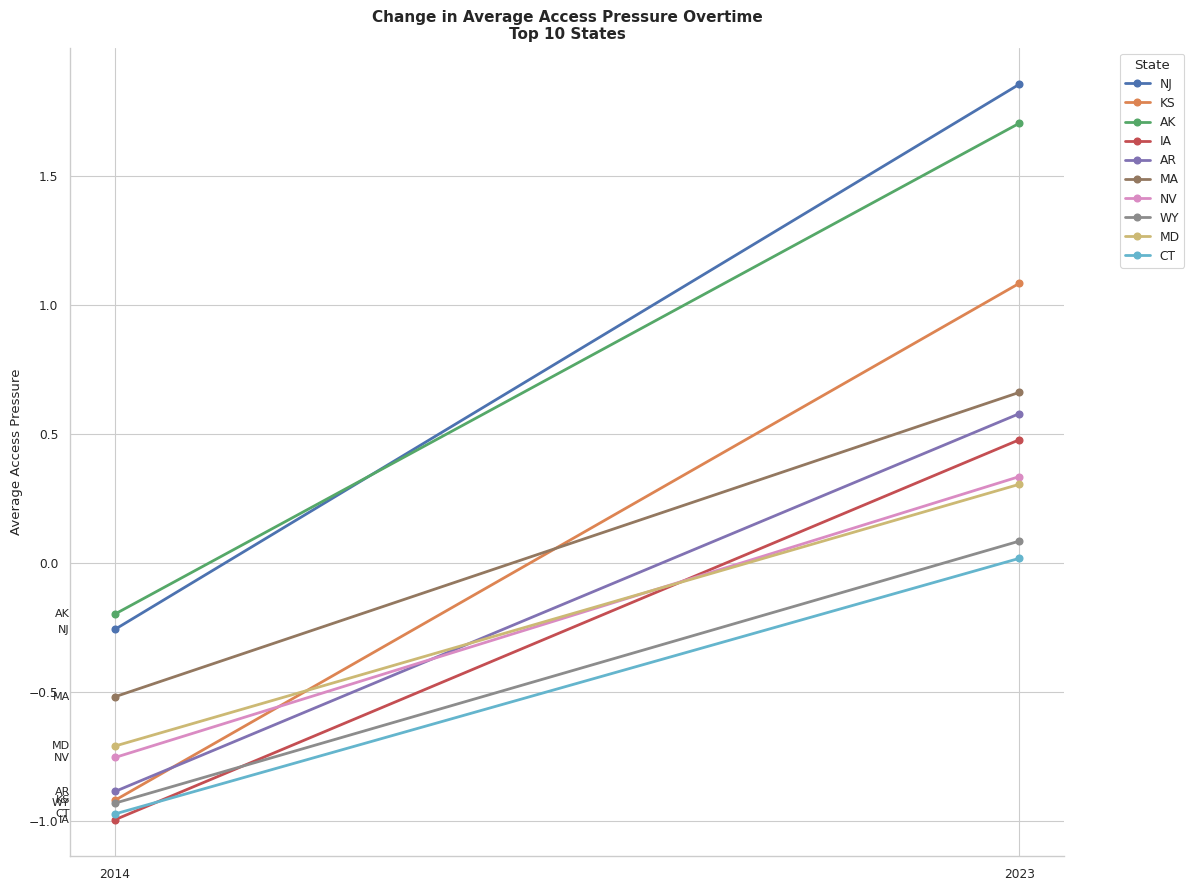

In [10]:
# Slope Chart
plot_df = (
    state_change
    .sort_values('pressure_change', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 9))

for _, row in plot_df.iterrows():
    ax.plot(
        [0, 1],
        [row['first_year_pressure'], row['last_year_pressure']],
        marker='o',
        linewidth=2,
        label=row['State_y']
    )

    ax.text(
        -0.05,
        row['first_year_pressure'],
        row['State_y'],
        ha='right',
        va='center',
        fontsize=8
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(['2014', '2023'])

ax.set_ylabel('Average Access Pressure')
ax.set_title(
    'Change in Average Access Pressure Overtime\nTop 10 States',
    fontsize=11,
    weight='bold'
)

ax.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

### County-level Change in Pharmacies' Access Pressure  

The change in access pressure from 2014 to 2023 provides the picture of counties that have overtime experienced greatest pharmacy deserts creation through highest increase in the access pressure change for access to pharmacies based on changes on year to year number of beneficiaries per pharmacy (beneficiary load). At county level the actual highest increases in the access pressure change for access to pharmacies provided information on highest at risk counties.

In [11]:
# County-year averages
county_year = (
    df.groupby(['State_y', 'County', 'year'])['access_pressure_change_TDF']
      .mean()
      .reset_index()
)

# Earliest and latest years
first_year = county_year['year'].min()
last_year = county_year['year'].max()

# Values in earliest year
first = (
    county_year[county_year['year'] == first_year]
    [['State_y', 'County', 'access_pressure_change_TDF']]
    .rename(columns={'access_pressure_change_TDF': 'first_pressure'})
)

# Values in latest year
last = (
    county_year[county_year['year'] == last_year]
    [['State_y', 'County', 'access_pressure_change_TDF']]
    .rename(columns={'access_pressure_change_TDF': 'last_pressure'})
)

# Compute change
county_change = (
    first.merge(last, on=['State_y', 'County'])
         .assign(
             pressure_change=lambda x:
             x['last_pressure'] - x['first_pressure']
         )
)

# Top 10 counties with largest increase
top10_county = (
    county_change
    .sort_values('pressure_change', ascending=False)
    .head(10)
    .copy()
)

top10_county

,State_y,County,first_pressure,last_pressure,pressure_change
26,GA,Lowndes,49.195755,126.024367,76.828611
78,NY,Chautauqua,-0.925726,39.089899,40.015625
103,VA,Newport News City,-0.911143,31.594571,32.505714
20,GA,Baker,-0.942376,30.647300,31.589677
23,GA,Early,-0.905671,22.372759,23.278429
36,KS,Sedgwick,-0.962947,21.499723,22.462670
62,NC,Alamance,-0.953749,20.003090,20.956839
41,LA,Lafourche,-0.940765,19.265782,20.206547
54,MI,Gogebic,-0.490048,19.366469,19.856517
11,CA,Imperial,-0.976459,16.001167,16.977626


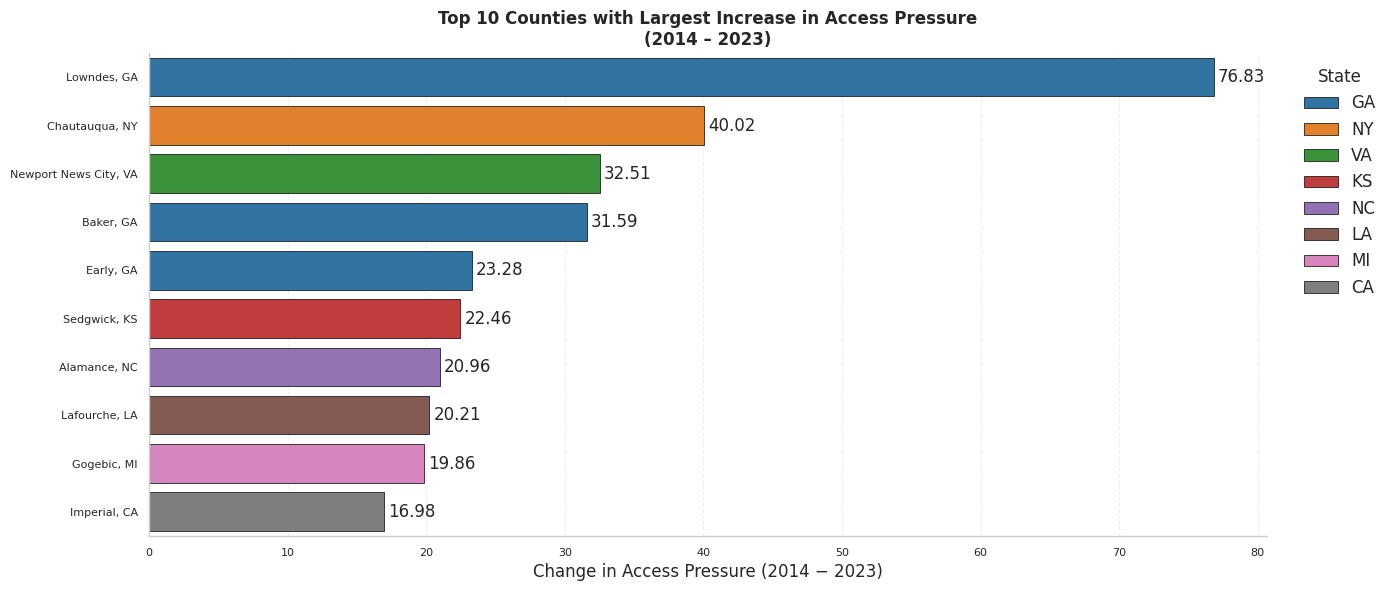

In [12]:
# Creating county-state
top10_county['county_state'] = (
    top10_county['County'] + ', ' + top10_county['State_y']
)

# Create a color palette for states
states = top10_county['State_y'].unique()

palette = dict(
    zip(
        states,
        sns.color_palette("tab10", n_colors=len(states))
    )
)

sns.set_theme(style="whitegrid", context="paper")

fig, ax = plt.subplots(figsize=(14, 6))

bars = sns.barplot(
    data=top10_county,
    y='county_state',
    x='pressure_change',
    hue='State_y',
    palette=palette,
    edgecolor='black',
    linewidth=0.5,
    dodge=False,
    ax=ax
)

# Value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3,
        fontsize=12
    )

ax.set_title(
    'Top 10 Counties with Largest Increase in Access Pressure\n(2014 – 2023)',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel(
    'Change in Access Pressure (2014 − 2023)',
    fontsize=12
)

ax.set_ylabel('')

ax.tick_params(axis='both', labelsize=8)

# Move legend outside plot
ax.legend(
    title='State',
    fontsize=12,
    title_fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.show()

### County and Year with Highest Access Pressure Change

In [13]:
# Access Pressure Change Descriptive Statistics
county_year['access_pressure_change_TDF'].describe().round(3)

,access_pressure_change_TDF
count,15745.000
mean,0.656
std,7.461
min,-1.000
25%,-0.006
50%,0.071
75%,0.178
max,530.905


In [14]:
# Top 10 Counties with highest access pressure change across all years
top10_county_year = (
    county_year
    .nlargest(10, 'access_pressure_change_TDF')
    .reset_index(drop=True)
)

top10_county_year

,State_y,County,year,access_pressure_change_TDF
0,NY,Chenango,2019,530.904762
1,MS,Washington,2018,352.000000
2,IL,Saline,2019,272.916667
3,ND,Stutsman,2018,246.192982
4,ND,Stutsman,2016,179.888813
5,NC,Rutherford,2020,154.237697
6,NY,Otsego,2019,144.511278
7,NC,Rutherford,2018,140.126045
8,TX,Pecos,2021,128.709812
9,GA,Lowndes,2021,126.024367


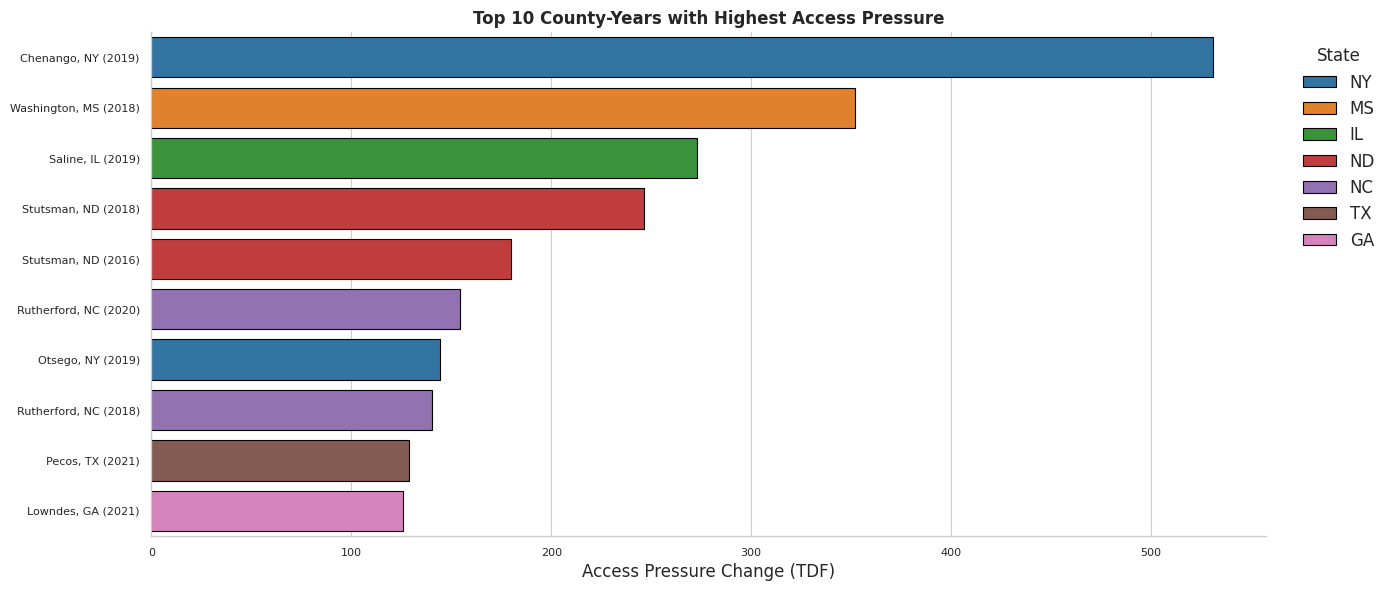

In [15]:
# Plot for top 10 counties with highest actual access pressure change across all years

# County - State - Year Aattribute
top10_county_year['county_state_year'] = (
    top10_county_year['County']
    + ', '
    + top10_county_year['State_y']
    + ' ('
    + top10_county_year['year'].astype(str)
    + ')'
)

# Plot
sns.set_theme(style="whitegrid", context="paper")

fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=top10_county_year,
    y='county_state_year',
    x='access_pressure_change_TDF',
    hue='State_y',
    dodge=False,
    palette='tab10',
    edgecolor='black',
    ax=ax
)

ax.set_title(
    'Top 10 County-Years with Highest Access Pressure',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel('Access Pressure Change (TDF)', fontsize=12)
ax.set_ylabel('')

ax.tick_params(labelsize=8)

ax.legend(
    title='State',
    fontsize=12,
    title_fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

### State-Level Desert Formation Risk Exposure


The percentages of counties exposed to high risk over time provide information on the extent of exposure to high risk of pharamcy deserts per state.

In [16]:
# State
ct = pd.crosstab(
    df['State_y'],
    df['Desert_Formation_Risk']
)

# Convert to percentages within state
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct

Desert_Formation_Risk,High Risk,Low Risk
State_y,,
AK,36.153846,63.846154
AL,21.077283,78.922717
AR,14.285714,85.714286
AZ,22.535211,77.464789
CA,17.204301,82.795699
CO,17.263844,82.736156
CT,12.962963,87.037037
DC,100.000000,0.000000
DE,0.000000,100.000000


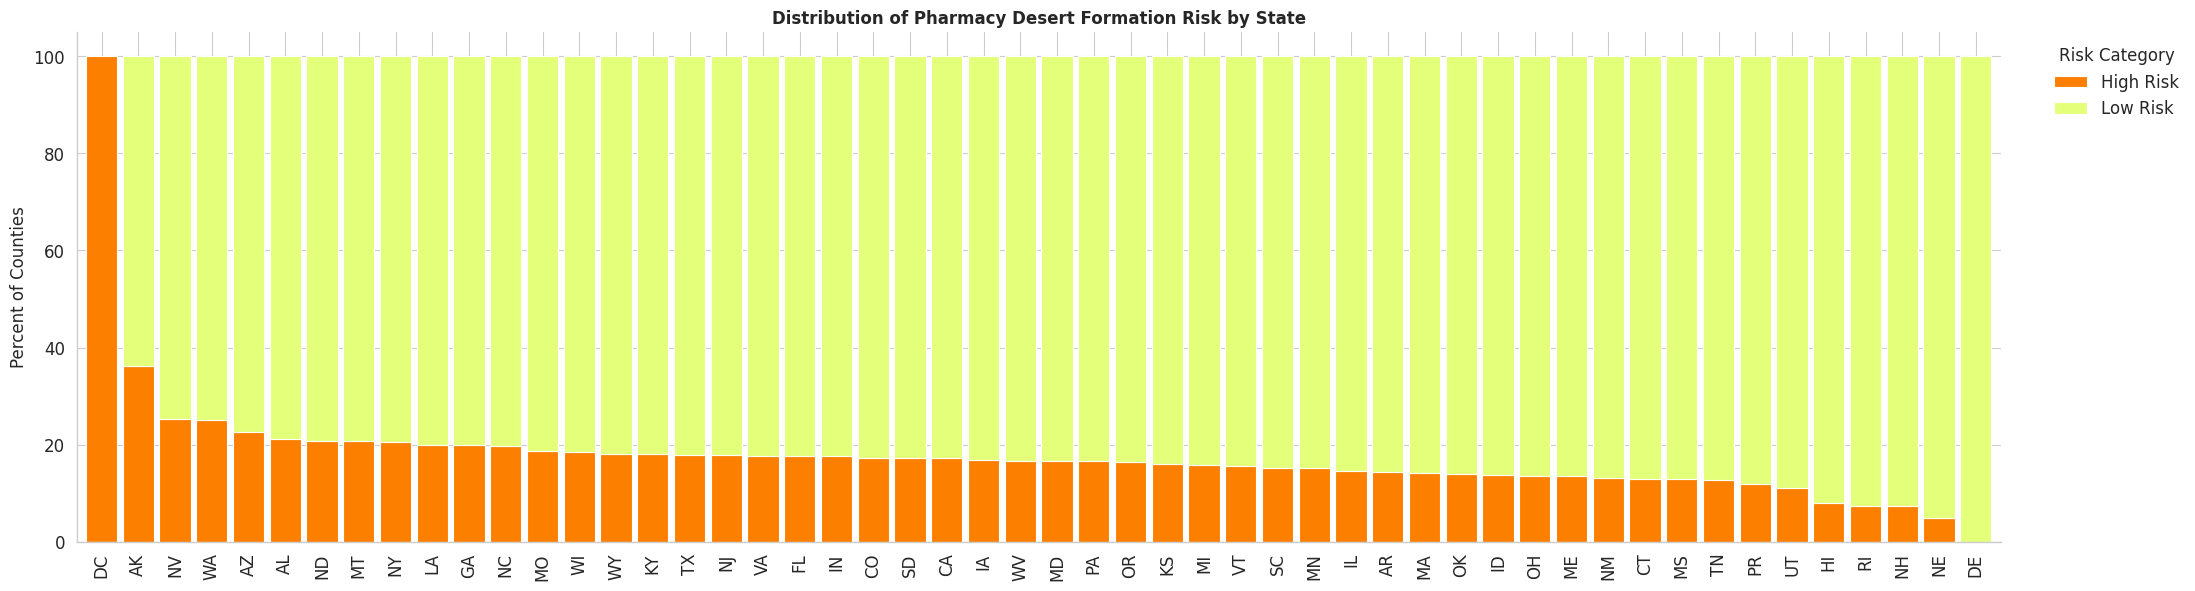

In [17]:
# Ploting state levele percentage exposure to high and low risk pharmacy desert formation
sns.set_theme(style="whitegrid", context="paper")

# Ordering states by % High Risk
if 'High Risk' in ct_pct.columns:
    ct_pct = ct_pct.sort_values('High Risk', ascending=False)

fig, ax = plt.subplots(figsize=(22, 6))

ct_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='Wistia_r',
    width=0.85
)

ax.set_title(
    'Distribution of Pharmacy Desert Formation Risk by State',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel('')
ax.set_ylabel('Percent of Counties', fontsize=12)

ax.tick_params(axis='x', labelsize=12, rotation=90)
ax.tick_params(axis='y', labelsize=12)

ax.legend(
    title='Risk Category',
    fontsize=12,
    title_fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Correlation Heatmap

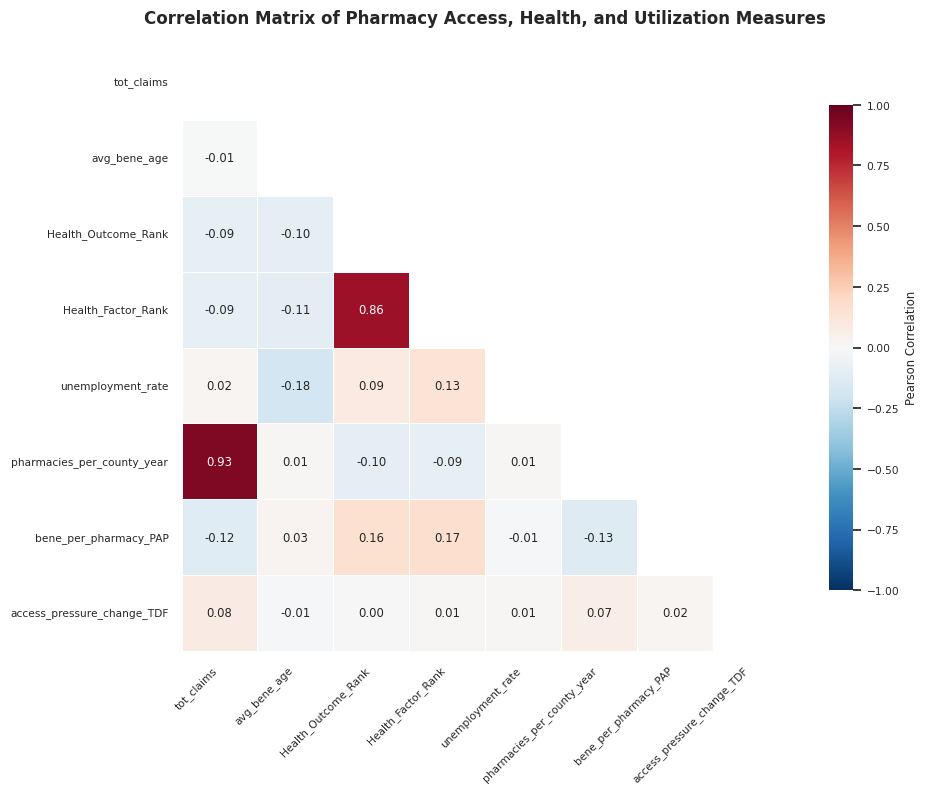

In [18]:
# Variables of interest
vars_ = [
    'tot_claims',
    'avg_bene_age',
    'Health_Outcome_Rank',
    'Health_Factor_Rank',
    'unemployment_rate',
    'pharmacies_per_county_year',
    'bene_per_pharmacy_PAP',
    'access_pressure_change_TDF'
]

# Correlation matrix
corr = df[vars_].corr()

# Masking upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10, 8))

sns.set_theme(style="white", font_scale=0.7)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"}
)

plt.title(
    "Correlation Matrix of Pharmacy Access, Health, and Utilization Measures",
    fontsize=12,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Average Yearly Trend in Beneficiaries per Pharmacy for Pharmacy Access Pressure Trend Analysis

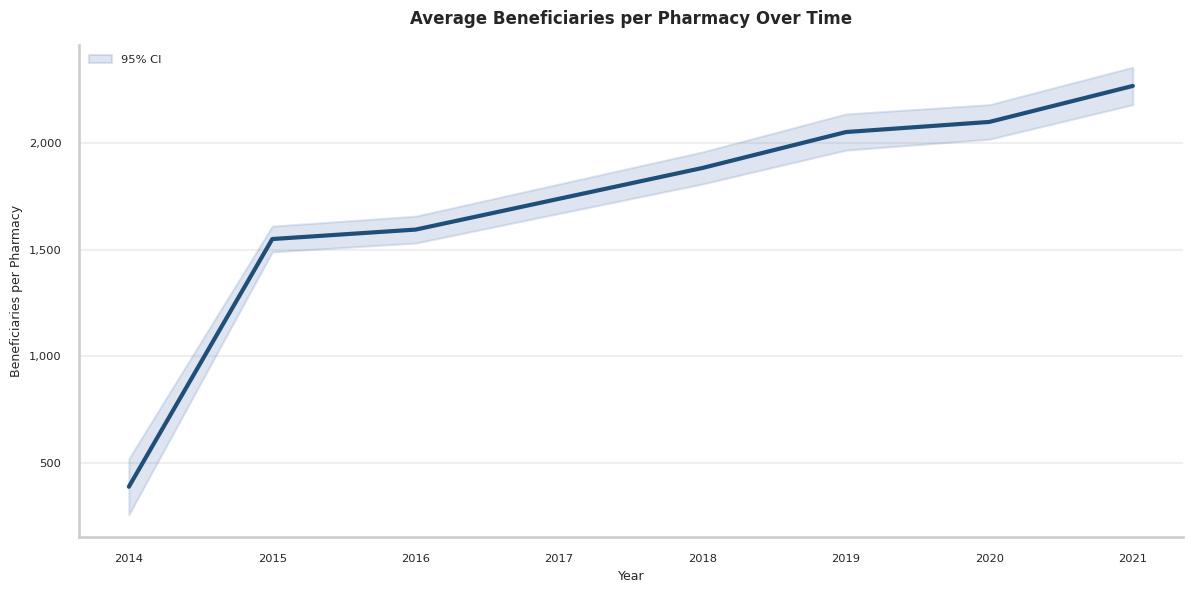

In [19]:
# Aggregate by year
yearly = (
    df.groupby('year', as_index=False)
      .agg(mean_bpp=('bene_per_pharmacy_PAP', 'mean'),
           std_bpp=('bene_per_pharmacy_PAP', 'std'),
           n=('bene_per_pharmacy_PAP', 'count'))
)

# 95% CI
yearly['se'] = yearly['std_bpp'] / yearly['n']**0.5
yearly['ci95'] = 1.96 * yearly['se']

# Professional style
sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.5
)

fig, ax = plt.subplots(figsize=(12, 6))

# Confidence band
ax.fill_between(
    yearly['year'],
    yearly['mean_bpp'] - yearly['ci95'],
    yearly['mean_bpp'] + yearly['ci95'],
    color='#4C72B0',
    alpha=0.18,
    label='95% CI'
)

# Trend line
sns.lineplot(
    data=yearly,
    x='year',
    y='mean_bpp',
    linewidth=3,
    markersize=8,
    color='#1F4E79',
    ax=ax
)

# Formatting
ax.set_title(
    'Average Beneficiaries per Pharmacy Over Time',
    fontsize=12,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Year', fontsize=9)
ax.set_ylabel('Beneficiaries per Pharmacy', fontsize=9)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'{x:,.0f}')
)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Subtle grid
ax.grid(True, axis='y', alpha=0.3)
ax.grid(False, axis='x')

# Legend
ax.legend(frameon=False, loc='best')

plt.tight_layout()
plt.show()

### Average County Yearly Trend in Unemployment Rate by Desert Formation Risk for comparison between High Risk and Low Risk County Averages.

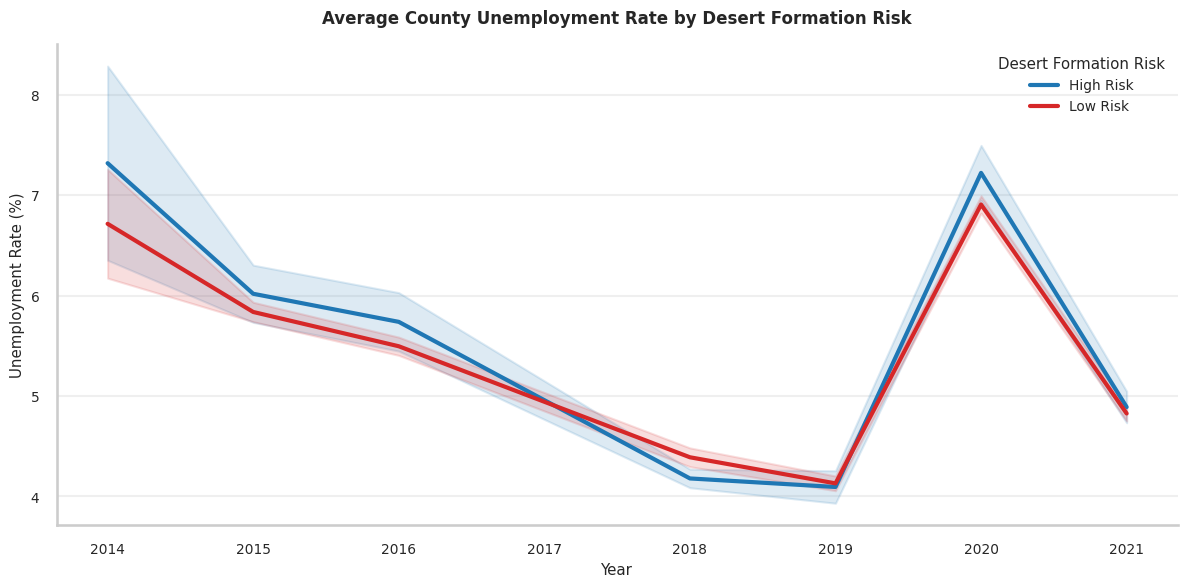

In [20]:
# Aggregate
yearly = (
    df.groupby(['year', 'Desert_Formation_Risk'])
      .agg(
          mean_unemp=('unemployment_rate', 'mean'),
          std_unemp=('unemployment_rate', 'std'),
          n=('unemployment_rate', 'count')
      )
      .reset_index()
)

# 95% confidence intervals
yearly['se'] = yearly['std_unemp'] / np.sqrt(yearly['n'])
yearly['ci95'] = 1.96 * yearly['se']

# Plot style
sns.set_theme(
    style='whitegrid',
    context='talk',
    font_scale=0.6
)

fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    yearly['Desert_Formation_Risk'].unique()[0]: '#1F77B4',
    yearly['Desert_Formation_Risk'].unique()[1]: '#D62728'
}

for risk in yearly['Desert_Formation_Risk'].unique():

    temp = yearly[yearly['Desert_Formation_Risk'] == risk]

    # Confidence band
    ax.fill_between(
        temp['year'],
        temp['mean_unemp'] - temp['ci95'],
        temp['mean_unemp'] + temp['ci95'],
        alpha=0.15,
        color=colors[risk]
    )

    # Trend line
    ax.plot(
        temp['year'],
        temp['mean_unemp'],
        linewidth=3,
        markersize=7,
        color=colors[risk],
        label=risk
    )

# Formatting
ax.set_title(
    'Average County Unemployment Rate by Desert Formation Risk',
    fontsize=12,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Year')
ax.set_ylabel('Unemployment Rate (%)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, axis='y', alpha=0.3)
ax.grid(False, axis='x')

ax.legend(
    title='Desert Formation Risk',
    frameon=False,
    loc='best'
)

plt.tight_layout()
plt.show()

## EDA Summary

This notebook completed exploratory data analysis for the pharmacy desert risk prediction project.

Key findings:
• Pharmacy access pressure varied across states and counties.
• Some counties showed sharp increases in PAP over time.
• Lowndes, GA was one of the counties with the largest access pressure increase.
• The EDA confirmed that county-level pharmacy desert risk patterns exist.
• Correlation analysis showed relationships between pharmacy utilization, health rankings, unemployment, and access pressure.
• These findings supported the need for machine learning models to classify counties as Low Risk or High Risk.

Next step:
The next notebook will train and evaluate machine learning models, including XGBoost, LSTM, ST-GNN, HGNN, and Tensor Train.